In [ ]:
RANDOM_STATE = 42
OUT_DIR = "runs"
RUN_NAME = "elliptic"

In [ ]:
# =========================================
# 0. Import & cấu hình chung
# =========================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from scipy.stats import randint, uniform



# Thư mục chứa các file Elliptic (sửa lại cho đúng máy bạn)
DATA_DIR = r"D:\elliptic\Elliptic_Dataset"
TXS_FEATURES_FILE = "txs_features.csv"
TXS_CLASSES_FILE  = "txs_classes.csv"
TXS_EDGELIST_FILE = "txs_edgelist.csv"  # nếu cần cho GNN thì dùng thêm, ở đây chưa cần

In [2]:
# =========================================
# 1. Load dataset
# =========================================
import os

df_txs_features = pd.read_csv(os.path.join(DATA_DIR, TXS_FEATURES_FILE))
df_txs_classes  = pd.read_csv(os.path.join(DATA_DIR, TXS_CLASSES_FILE))

print("txs_features shape:", df_txs_features.shape)
print("txs_classes  shape:", df_txs_classes.shape)
print("txs_features columns:", df_txs_features.columns.tolist())
print("txs_classes  columns:", df_txs_classes.columns.tolist())


txs_features shape: (203769, 184)
txs_classes  shape: (203769, 2)
txs_features columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8', 'Local_feature_9', 'Local_feature_10', 'Local_feature_11', 'Local_feature_12', 'Local_feature_13', 'Local_feature_14', 'Local_feature_15', 'Local_feature_16', 'Local_feature_17', 'Local_feature_18', 'Local_feature_19', 'Local_feature_20', 'Local_feature_21', 'Local_feature_22', 'Local_feature_23', 'Local_feature_24', 'Local_feature_25', 'Local_feature_26', 'Local_feature_27', 'Local_feature_28', 'Local_feature_29', 'Local_feature_30', 'Local_feature_31', 'Local_feature_32', 'Local_feature_33', 'Local_feature_34', 'Local_feature_35', 'Local_feature_36', 'Local_feature_37', 'Local_feature_38', 'Local_feature_39', 'Local_feature_40', 'Local_feature_41', 'Local_feature_42', 'Local_feature_43', 'Local_feature_44', 'Local_feature_45',

In [3]:
# =========================================
# 2. Merge & xử lý label
# =========================================
# Giả định:
#   - df_txs_features có cột 'txId' và 'Time step' (hoặc 'time_step')
#   - df_txs_classes có cột 'txId' và 'class'
#   - class:
#       1 = licit
#       2 = illicit
#       3 = unknown
# Ta drop class=3, và tạo label nhị phân: 0=licit, 1=illicit

df = df_txs_features.merge(df_txs_classes, on="txId", how="left")

if "class" not in df.columns:
    raise ValueError("Không tìm thấy cột 'class' sau khi merge!")

print("\nPhân bố class ban đầu:")
print(df["class"].value_counts(dropna=False))

# Bỏ các giao dịch không có nhãn hoặc nhãn 'unknown' = 3
df = df.dropna(subset=["class"]).copy()
df["class"] = df["class"].astype(int)
df = df[df["class"] != 3].copy()

# Tạo label nhị phân: 0=licit, 1=illicit
df["label"] = (df["class"] == 2).astype(int)

LABEL_COL = "label"
print("\nPhân bố label sau khi bỏ unknown (0=licit,1=illicit):")
print(df[LABEL_COL].value_counts())


Phân bố class ban đầu:
class
3    157205
2     42019
1      4545
Name: count, dtype: int64

Phân bố label sau khi bỏ unknown (0=licit,1=illicit):
label
1    42019
0     4545
Name: count, dtype: int64


In [4]:
# =========================================
# 3. Chọn feature (loại id/time/label)
# =========================================
# Cột id / thời gian không dùng làm feature
possible_ts_cols = ["Time step", "time_step"]
ts_col = None
for c in possible_ts_cols:
    if c in df.columns:
        ts_col = c
        break

if ts_col is None:
    raise ValueError("Không tìm thấy cột time-step (ví dụ 'Time step' hoặc 'time_step')!")

drop_id_cols = ["txId", ts_col]
drop_label_cols = ["class", LABEL_COL]

cols_to_drop = [c for c in drop_id_cols + drop_label_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in cols_to_drop]

X_df = df[feature_cols].copy()
y = df[LABEL_COL].values
time_steps = df[ts_col].values

print("\nSố feature:", len(feature_cols))
print("Một vài feature đầu:", feature_cols[:10])

# Chỉ giữ các cột số
num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
X_df = X_df[num_cols].copy()
print("\nSố feature numeric:", len(num_cols))


Số feature: 182
Một vài feature đầu: ['Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8', 'Local_feature_9', 'Local_feature_10']

Số feature numeric: 182


In [5]:
# =========================================
# 4. Chia train/val/test THEO TIME_STEP (30/10/10)
# =========================================
unique_ts = np.sort(df[ts_col].unique())
n_ts = len(unique_ts)
print("\nSố time-step khác nhau:", n_ts)
print("Các time-step đầu:", unique_ts[:10], "...", unique_ts[-10:])

# Nếu đúng Elliptic (49 time-step), ta dùng 30/10/9
# Nếu >= 50, dùng đúng 30/10/10
# Nếu ít hơn thì chia theo tỉ lệ 60/20/20
if n_ts == 49:
    train_ts = unique_ts[:34]
    val_ts   = unique_ts[34:41]
    test_ts  = unique_ts[41:]
elif n_ts >= 50:
    train_ts = unique_ts[:30]
    val_ts   = unique_ts[30:40]
    test_ts  = unique_ts[40:50]
else:
    # fallback: chia theo tỉ lệ tương đối
    idx_train_end = int(0.6 * n_ts)
    idx_val_end   = int(0.8 * n_ts)
    train_ts = unique_ts[:idx_train_end]
    val_ts   = unique_ts[idx_train_end:idx_val_end]
    test_ts  = unique_ts[idx_val_end:]

print("\nTime-step TRAIN:", train_ts[0], "->", train_ts[-1])
print("Time-step VAL  :", val_ts[0],   "->", val_ts[-1])
print("Time-step TEST :", test_ts[0],  "->", test_ts[-1])

train_mask = df[ts_col].isin(train_ts)
val_mask   = df[ts_col].isin(val_ts)
test_mask  = df[ts_col].isin(test_ts)

X_train = X_df[train_mask].values
y_train = y[train_mask]

X_val   = X_df[val_mask].values
y_val   = y[val_mask]

X_test  = X_df[test_mask].values
y_test  = y[test_mask]

print("\nKích thước:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\nPhân bố nhãn train:")
print(pd.Series(y_train).value_counts())
print("\nPhân bố nhãn val:")
print(pd.Series(y_val).value_counts())
print("\nPhân bố nhãn test:")
print(pd.Series(y_test).value_counts())


Số time-step khác nhau: 49
Các time-step đầu: [ 1  2  3  4  5  6  7  8  9 10] ... [40 41 42 43 44 45 46 47 48 49]

Time-step TRAIN: 1 -> 34
Time-step VAL  : 35 -> 41
Time-step TEST : 42 -> 49

Kích thước:
X_train: (29894, 182) y_train: (29894,)
X_val  : (7829, 182) y_val  : (7829,)
X_test : (8841, 182) y_test : (8841,)

Phân bố nhãn train:
1    26432
0     3462
Name: count, dtype: int64

Phân bố nhãn val:
1    7154
0     675
Name: count, dtype: int64

Phân bố nhãn test:
1    8433
0     408
Name: count, dtype: int64


In [6]:
# =========================================
# 5. Chuẩn hóa feature (fit trên TRAIN)
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [7]:
# =========================================
# 6. AutoML đơn giản: random search trên VAL (macro-F1)
#    Không dùng k-fold
# =========================================
def sample_param(dist, rng):
    """Lấy 1 giá trị từ distribution hoặc list."""
    if hasattr(dist, "rvs"):
        # scipy distribution
        return dist.rvs(random_state=rng)
    # list / tuple / set ...
    dist = list(dist)
    return dist[rng.randint(0, len(dist))]

def random_search_single_model(
    name,
    base_estimator,
    param_dist,
    X_train, y_train,
    X_val,   y_val,
    n_iter=30,
    scoring="macro"
):
    """
    Random search đơn giản:
      - Mỗi iter: sample 1 bộ siêu tham số
      - Train trên TRAIN
      - Đánh giá trên VAL theo F1-macro
      - Chọn bộ tốt nhất, rồi train lại trên TRAIN+VAL với bộ đó
    """
    print(f"\n===== Random search cho {name} (không k-fold, dùng VAL) =====")
    rng = np.random.RandomState(RANDOM_STATE)
    best_f1 = -1.0
    best_params = None

    for i in range(n_iter):
        params = {k: sample_param(v, rng) for k, v in param_dist.items()}

        model = clone(base_estimator)
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        # macro-F1 dùng để chọn model
        f1_macro = f1_score(y_val, y_val_pred, average="macro")

        print(f"Iter {i+1:02d}/{n_iter}: F1_macro(val) = {f1_macro:.4f}, params = {params}")

        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_params = params

    print(f"\n>>> {name} – best F1_macro(val) = {best_f1:.4f}")
    print("Best params:", best_params)

    # Train lại trên TRAIN+VAL với best_params trước khi test
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    best_model = clone(base_estimator)
    best_model.set_params(**best_params)
    best_model.fit(X_train_full, y_train_full)

    return best_model

# Tính scale_pos_weight cho XGB/LGBM
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
print("\nscale_pos_weight (train):", scale_pos_weight)


scale_pos_weight (train): 0.130977602905569


In [8]:
# =========================================
# 7. Định nghĩa search space & chạy AutoML cho RF / XGB / LGBM
# =========================================

# 1) RandomForest
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
    # thêm criterion vào hyperparameter search
    "criterion": ["gini", "entropy"],  # nếu sklearn mới có thể thêm "log_loss"
}

best_rf = random_search_single_model(
    "RandomForest",
    rf_base,
    rf_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)







===== Random search cho RandomForest (không k-fold, dùng VAL) =====
Iter 01/30: F1_macro(val) = 0.9099, params = {'n_estimators': 302, 'max_depth': 22, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 02/30: F1_macro(val) = 0.8879, params = {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 11, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 03/30: F1_macro(val) = 0.9564, params = {'n_estimators': 299, 'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': None, 'criterion': 'entropy'}
Iter 04/30: F1_macro(val) = 0.9208, params = {'n_estimators': 543, 'max_depth': 14, 'min_samples_split': 31, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': 'balanced', 'criterion': 'entropy'}
Iter 05/30: F1_macro(val) = 0.9234, params = {'n_estimators': 476, 'max_depth': 3, 'min_samples_split': 13, 'min_s

In [9]:
# 2) XGBoost
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    tree_method="hist",      # hoặc "gpu_hist" nếu chạy GPU
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),         # [0.6, 1.0]
    "colsample_bytree": uniform(0.6, 0.4),  # [0.6, 1.0]
    "min_child_weight": randint(1, 10),
    "reg_lambda": uniform(0, 5),
    "objective": ["binary:logistic"],       # thường giữ nguyên cái này
    "eval_metric": ["logloss", "aucpr"],    # cho AutoML thử 2 metric
    "scale_pos_weight": [scale_pos_weight]
}

best_xgb = random_search_single_model(
    "XGBoost",
    xgb_base,
    xgb_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== Random search cho XGBoost (không k-fold, dùng VAL) =====


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 01/30: F1_macro(val) = 0.9367, params = {'n_estimators': 302, 'max_depth': 6, 'learning_rate': np.float64(0.28570714885887566), 'subsample': np.float64(0.892797576724562), 'colsample_bytree': np.float64(0.8394633936788146), 'min_child_weight': 7, 'reg_lambda': np.float64(2.229163764267956), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 02/30: F1_macro(val) = 0.9364, params = {'n_estimators': 530, 'max_depth': 10, 'learning_rate': np.float64(0.10677549723031632), 'subsample': np.float64(0.6571467271687763), 'colsample_bytree': np.float64(0.8603553891795411), 'min_child_weight': 5, 'reg_lambda': np.float64(4.8495492608099715), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 03/30: F1_macro(val) = 0.8799, params = {'n_estimators': 613, 'max_depth': 8, 'learning_rate': np.float64(0.010225842093894155), 'subsample': np.float64(0.996884623716487), 'colsample_bytree': np.float64(0.8469926038510867), 'min_child_weight': 6, 'reg_lambda': np.float64(0.03533152609858703), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 04/30: F1_macro(val) = 0.9408, params = {'n_estimators': 760, 'max_depth': 5, 'learning_rate': np.float64(0.12091397746747719), 'subsample': np.float64(0.9932923543227152), 'colsample_bytree': np.float64(0.786705157299192), 'min_child_weight': 5, 'reg_lambda': np.float64(3.0377242595071916), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 05/30: F1_macro(val) = 0.9368, params = {'n_estimators': 366, 'max_depth': 4, 'learning_rate': np.float64(0.2851768058034666), 'subsample': np.float64(0.9862528132298237), 'colsample_bytree': np.float64(0.9233589392465844), 'min_child_weight': 9, 'reg_lambda': np.float64(0.07983126110107097), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 06/30: F1_macro(val) = 0.9466, params = {'n_estimators': 539, 'max_depth': 9, 'learning_rate': np.float64(0.18689903075696007), 'subsample': np.float64(0.9332779646944658), 'colsample_bytree': np.float64(0.6693458614031088), 'min_child_weight': 1, 'reg_lambda': np.float64(1.2938999080000846), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 07/30: F1_macro(val) = 0.9456, params = {'n_estimators': 587, 'max_depth': 4, 'learning_rate': np.float64(0.13329520360246094), 'subsample': np.float64(0.6831766651472755), 'colsample_bytree': np.float64(0.8270801311279966), 'min_child_weight': 2, 'reg_lambda': np.float64(3.8756641168055728), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 08/30: F1_macro(val) = 0.9378, params = {'n_estimators': 401, 'max_depth': 6, 'learning_rate': np.float64(0.18339099385521468), 'subsample': np.float64(0.9687496940092467), 'colsample_bytree': np.float64(0.6353970008207678), 'min_child_weight': 7, 'reg_lambda': np.float64(2.6041713001291185), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 09/30: F1_macro(val) = 0.9280, params = {'n_estimators': 495, 'max_depth': 7, 'learning_rate': np.float64(0.12271641400994977), 'subsample': np.float64(0.7085396127095583), 'colsample_bytree': np.float64(0.9314950036607718), 'min_child_weight': 9, 'reg_lambda': np.float64(1.4046725484369038), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 10/30: F1_macro(val) = 0.9286, params = {'n_estimators': 692, 'max_depth': 11, 'learning_rate': np.float64(0.09591931665418388), 'subsample': np.float64(0.6661067756252009), 'colsample_bytree': np.float64(0.6062545626964776), 'min_child_weight': 9, 'reg_lambda': np.float64(3.861223846483287), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 11/30: F1_macro(val) = 0.9413, params = {'n_estimators': 671, 'max_depth': 5, 'learning_rate': np.float64(0.21498862971580895), 'subsample': np.float64(0.8916028672163949), 'colsample_bytree': np.float64(0.9085081386743783), 'min_child_weight': 5, 'reg_lambda': np.float64(4.631504392566745), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 12/30: F1_macro(val) = 0.9371, params = {'n_estimators': 240, 'max_depth': 9, 'learning_rate': np.float64(0.2565111875590418), 'subsample': np.float64(0.7797802696552814), 'colsample_bytree': np.float64(0.6381640465961645), 'min_child_weight': 7, 'reg_lambda': np.float64(1.554911608578311), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 13/30: F1_macro(val) = 0.9333, params = {'n_estimators': 298, 'max_depth': 10, 'learning_rate': np.float64(0.08966931996711859), 'subsample': np.float64(0.8244973703390804), 'colsample_bytree': np.float64(0.7531707499015159), 'min_child_weight': 3, 'reg_lambda': np.float64(3.803925243084487), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 14/30: F1_macro(val) = 0.9349, params = {'n_estimators': 702, 'max_depth': 9, 'learning_rate': np.float64(0.021725740966145088), 'subsample': np.float64(0.8842651558743149), 'colsample_bytree': np.float64(0.6443563283247326), 'min_child_weight': 3, 'reg_lambda': np.float64(0.15714592843367126), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 15/30: F1_macro(val) = 0.9358, params = {'n_estimators': 440, 'max_depth': 6, 'learning_rate': np.float64(0.17334991587315127), 'subsample': np.float64(0.878206434570451), 'colsample_bytree': np.float64(0.6557325817623503), 'min_child_weight': 7, 'reg_lambda': np.float64(2.0519146151781484), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 16/30: F1_macro(val) = 0.9483, params = {'n_estimators': 740, 'max_depth': 6, 'learning_rate': np.float64(0.2834275354618145), 'subsample': np.float64(0.8395461865954144), 'colsample_bytree': np.float64(0.8779139732158818), 'min_child_weight': 2, 'reg_lambda': np.float64(3.1217702406689662), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 17/30: F1_macro(val) = 0.9257, params = {'n_estimators': 227, 'max_depth': 6, 'learning_rate': np.float64(0.26884210956209353), 'subsample': np.float64(0.8157368967662603), 'colsample_bytree': np.float64(0.922976062065625), 'min_child_weight': 9, 'reg_lambda': np.float64(1.5900173748593194), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 18/30: F1_macro(val) = 0.9430, params = {'n_estimators': 584, 'max_depth': 11, 'learning_rate': np.float64(0.19783013495699506), 'subsample': np.float64(0.6002081507981263), 'colsample_bytree': np.float64(0.7410275425336676), 'min_child_weight': 3, 'reg_lambda': np.float64(0.03476065265595352), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 19/30: F1_macro(val) = 0.9396, params = {'n_estimators': 610, 'max_depth': 11, 'learning_rate': np.float64(0.15060069169410512), 'subsample': np.float64(0.8769744131561081), 'colsample_bytree': np.float64(0.7077649335194086), 'min_child_weight': 8, 'reg_lambda': np.float64(4.714548519562596), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 20/30: F1_macro(val) = 0.9371, params = {'n_estimators': 671, 'max_depth': 11, 'learning_rate': np.float64(0.12711248960683183), 'subsample': np.float64(0.6259568988435926), 'colsample_bytree': np.float64(0.7015661655737379), 'min_child_weight': 7, 'reg_lambda': np.float64(2.4862425294619275), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 21/30: F1_macro(val) = 0.9444, params = {'n_estimators': 280, 'max_depth': 3, 'learning_rate': np.float64(0.29321833719146934), 'subsample': np.float64(0.7644148053272926), 'colsample_bytree': np.float64(0.6132202931602193), 'min_child_weight': 1, 'reg_lambda': np.float64(3.171756723506819), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 22/30: F1_macro(val) = 0.9424, params = {'n_estimators': 329, 'max_depth': 7, 'learning_rate': np.float64(0.15194130048049329), 'subsample': np.float64(0.9942601816442402), 'colsample_bytree': np.float64(0.6968221086046001), 'min_child_weight': 4, 'reg_lambda': np.float64(0.40426663166357624), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 23/30: F1_macro(val) = 0.9369, params = {'n_estimators': 322, 'max_depth': 3, 'learning_rate': np.float64(0.22118274109743927), 'subsample': np.float64(0.7471132530877013), 'colsample_bytree': np.float64(0.8529223322374317), 'min_child_weight': 6, 'reg_lambda': np.float64(1.9941222122227653), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 24/30: F1_macro(val) = 0.8924, params = {'n_estimators': 343, 'max_depth': 3, 'learning_rate': np.float64(0.05370808774997454), 'subsample': np.float64(0.8032795106962874), 'colsample_bytree': np.float64(0.8783251227163527), 'min_child_weight': 3, 'reg_lambda': np.float64(2.954464715941209), 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 25/30: F1_macro(val) = 0.9286, params = {'n_estimators': 602, 'max_depth': 5, 'learning_rate': np.float64(0.24475530338051746), 'subsample': np.float64(0.7394663949166917), 'colsample_bytree': np.float64(0.6384706204365683), 'min_child_weight': 9, 'reg_lambda': np.float64(3.45468869051233), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 26/30: F1_macro(val) = 0.9447, params = {'n_estimators': 750, 'max_depth': 4, 'learning_rate': np.float64(0.2529359307131251), 'subsample': np.float64(0.8702760468157122), 'colsample_bytree': np.float64(0.8940864476963089), 'min_child_weight': 2, 'reg_lambda': np.float64(4.623468091392814), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 27/30: F1_macro(val) = 0.9422, params = {'n_estimators': 497, 'max_depth': 5, 'learning_rate': np.float64(0.0762795063212169), 'subsample': np.float64(0.6699819708383744), 'colsample_bytree': np.float64(0.9928673373317742), 'min_child_weight': 4, 'reg_lambda': np.float64(2.6482528917800323), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 28/30: F1_macro(val) = 0.9462, params = {'n_estimators': 503, 'max_depth': 7, 'learning_rate': np.float64(0.2711212365773658), 'subsample': np.float64(0.8532405829093072), 'colsample_bytree': np.float64(0.7356119164194803), 'min_child_weight': 3, 'reg_lambda': np.float64(3.5017891498638565), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:46:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 29/30: F1_macro(val) = 0.9500, params = {'n_estimators': 330, 'max_depth': 6, 'learning_rate': np.float64(0.267255063036884), 'subsample': np.float64(0.9119502183430496), 'colsample_bytree': np.float64(0.8568126584617151), 'min_child_weight': 1, 'reg_lambda': np.float64(0.8081435704730688), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:46:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 30/30: F1_macro(val) = 0.9309, params = {'n_estimators': 303, 'max_depth': 6, 'learning_rate': np.float64(0.17839912021657184), 'subsample': np.float64(0.7489131066246972), 'colsample_bytree': np.float64(0.9760533769831113), 'min_child_weight': 9, 'reg_lambda': np.float64(0.025307919231093434), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}

>>> XGBoost – best F1_macro(val) = 0.9500
Best params: {'n_estimators': 330, 'max_depth': 6, 'learning_rate': np.float64(0.267255063036884), 'subsample': np.float64(0.9119502183430496), 'colsample_bytree': np.float64(0.8568126584617151), 'min_child_weight': 1, 'reg_lambda': np.float64(0.8081435704730688), 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:46:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [10]:
# 3) LightGBM
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    objective="binary",
    n_jobs=-1
)

lgbm_param_dist = {
    "n_estimators": randint(200, 800),
    "num_leaves": randint(15, 255),
    "max_depth": randint(3, 12),            # -1 = no limit
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.6, 0.4),          # bagging_fraction
    "colsample_bytree": uniform(0.6, 0.4),   # feature_fraction
    "min_child_samples": randint(10, 100),
    "reg_lambda": uniform(0, 5),
    # --------- "criterion" kiểu LightGBM: objective + metric ----------
    "objective": ["binary"],                      # có thể thêm "xentropy"
    "metric": ["binary_logloss", "auc", "aucpr"],  # AutoML tự chọn
    "scale_pos_weight": [scale_pos_weight]
} 

best_lgbm = random_search_single_model(
    "LightGBM",
    lgbm_base,
    lgbm_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== Random search cho LightGBM (không k-fold, dùng VAL) =====
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 02/30: F1_macro(val) = 0.9521, params = {'n_estimators': 299, 'num_leaves': 118, 'max_depth': 10, 'learning_rate': np.float64(0.19875765715516733), 'subsample': np.float64(0.6225646316108401), 'colsample_bytree': np.float64(0.8887995089067299), 'min_child_samples': 39, 'reg_lambda': np.float64(1.0616955533913808), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41930
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 07/30: F1_macro(val) = 0.9511, params = {'n_estimators': 765, 'num_leaves': 120, 'max_depth': 6, 'learning_rate': np.float64(0.06360779210240283), 'subsample': np.float64(0.9878338511058234), 'colsample_bytree': np.float64(0.9100531293444458), 'min_child_samples': 43, 'reg_lambda': np.float64(1.9757511800090721), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 08/30: F1_macro(val) = 0.9460, params = {'n_estimators': 470, 'num_leaves': 214, 'max_depth': 9, 'learning_rate': np.float64(0.16104193540748887), 'subsample': np.float64(0.9844688097397396), 'colsample_bytree': np.float64(0.9378135394712606), 'min_child_samples': 91, 'reg_lambda': np.float64(2.698460661945399), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009571 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 12/30: F1_macro(val) = 0.9471, params = {'n_estimators': 661, 'num_leaves': 145, 'max_depth': 3, 'learning_rate': np.float64(0.21930156113781324), 'subsample': np.float64(0.6943939678995823), 'colsample_bytree': np.float64(0.7024273291045295), 'min_child_samples': 36, 'reg_lambda': np.float64(2.6136641469099704), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41930
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 15/30: F1_macro(val) = 0.9530, params = {'n_estimators': 773, 'num_leaves': 199, 'max_depth': 7, 'learning_rate': np.float64(0.2627235711544381), 'subsample': np.float64(0.9214688307596458), 'colsample_bytree': np.float64(0.6746280235544143), 'min_child_samples': 39, 'reg_lambda': np.float64(4.416401294594341), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 17/30: F1_macro(val) = 0.9481, params = {'n_estimators': 655, 'num_leaves': 169, 'max_depth': 11, 'learning_rate': np.float64(0.15060069169410512), 'subsample': np.float64(0.8769744131561081), 'colsample_bytree': np.float64(0.7077649335194086), 'min_child_samples': 33, 'reg_lambda': np.float64(4.714548519562596), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41930
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 20/30: F1_macro(val) = 0.9439, params = {'n_estimators': 252, 'num_leaves': 186, 'max_depth': 8, 'learning_rate': np.float64(0.0801960287383351), 'subsample': np.float64(0.8688542189623514), 'colsample_bytree': np.float64(0.9046478461314871), 'min_child_samples': 26, 'reg_lambda': np.float64(3.641081743059298), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41930
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 24/30: F1_macro(val) = 0.9523, params = {'n_estimators': 462, 'num_leaves': 158, 'max_depth': 11, 'learning_rate': np.float64(0.15982440846859414), 'subsample': np.float64(0.7043316699321636), 'colsample_bytree': np.float64(0.9985014799031697), 'min_child_samples': 21, 'reg_lambda': np.float64(2.791467268035488), 'objective': 'binary', 'metric': 'aucpr', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 26/30: F1_macro(val) = 0.9587, params = {'n_estimators': 619, 'num_leaves': 180, 'max_depth': 10, 'learning_rate': np.float64(0.18586442730128108), 'subsample': np.float64(0.6036788206466518), 'colsample_bytree': np.float64(0.6405886171464128), 'min_child_samples': 34, 'reg_lambda': np.float64(0.025307919231093434), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 29/30: F1_macro(val) = 0.9502, params = {'n_estimators': 574, 'num_leaves': 36, 'max_depth': 8, 'learning_rate': np.float64(0.2938789288997526), 'subsample': np.float64(0.794696861183782), 'colsample_bytree': np.float64(0.9624395150874216), 'min_child_samples': 36, 'reg_lambda': np.float64(3.974056517708242), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 26432, number of negative: 3462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41926
[LightGBM] [Info] Number of data points in the train set: 29894, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.884191 -> initscore=2.032729
[LightGBM] [Info] Start training from score 2.032729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 30/30: F1_macro(val) = 0.9280, params = {'n_estimators': 483, 'num_leaves': 125, 'max_depth': 3, 'learning_rate': np.float64(0.0666204664614329), 'subsample': np.float64(0.888980846104602), 'colsample_bytree': np.float64(0.7123089449763423), 'min_child_samples': 44, 'reg_lambda': np.float64(3.842770071531545), 'objective': 'binary', 'metric': 'binary_logloss', 'scale_pos_weight': np.float64(0.130977602905569)}

>>> LightGBM – best F1_macro(val) = 0.9587
Best params: {'n_estimators': 619, 'num_leaves': 180, 'max_depth': 10, 'learning_rate': np.float64(0.18586442730128108), 'subsample': np.float64(0.6036788206466518), 'colsample_bytree': np.float64(0.6405886171464128), 'min_child_samples': 34, 'reg_lambda': np.float64(0.025307919231093434), 'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(0.130977602905569)}
[LightGBM] [Info] Number of positive: 33586, number of negative: 4137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was

In [11]:
# =========================================================
# 7. ENSEMBLE (Voting) từ 3 model: 4 tổ hợp × (hard + soft)
#    - Không cần refit lại model (dùng best_rf/best_xgb/best_lgbm đã fit)
# =========================================================
from itertools import combinations
from sklearn.metrics import roc_auc_score

base_models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}

def _proba_pos(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()

def ensemble_predict(models_dict, X, voting="soft", threshold=0.5):
    models = list(models_dict.values())

    probas = np.vstack([_proba_pos(m, X) for m in models])  # [n_models, n_samples]
    proba_mean = probas.mean(axis=0)

    if voting == "soft":
        y_pred = (proba_mean >= threshold).astype(int)
        return y_pred, proba_mean

    if voting == "hard":
        preds = np.vstack([m.predict(X) for m in models]).astype(int)
        votes = preds.sum(axis=0)
        half = len(models) / 2

        y_pred = (votes > half).astype(int)

        # tie (chỉ xảy ra khi 2 model): dùng mean proba để phá hoà
        tie_mask = (votes == half)
        if np.any(tie_mask):
            y_pred[tie_mask] = (proba_mean[tie_mask] >= threshold).astype(int)

        return y_pred, proba_mean

    raise ValueError("voting phải là 'hard' hoặc 'soft'")

def eval_binary(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["f1_binary"] = f1_score(y_true, y_pred)
    out["f1_micro"]  = f1_score(y_true, y_pred, average="micro")
    out["f1_macro"]  = f1_score(y_true, y_pred, average="macro")
    if y_score is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            out["roc_auc"] = np.nan
    return out

results = []

# 4 tổ hợp: C(3,2)=3 + C(3,3)=1
combos = list(combinations(base_models.keys(), 2)) + [tuple(base_models.keys())]

for combo in combos:
    combo_models = {k: base_models[k] for k in combo}
    combo_name = "+".join(combo)

    for voting in ["hard", "soft"]:
        y_pred, y_score = ensemble_predict(combo_models, X_test_scaled, voting=voting, threshold=0.5)
        m = eval_binary(y_test, y_pred, y_score)
        
        results.append({"ensemble": combo_name, "voting": voting, **m})

        print(f"\n===== Ensemble [{combo_name}] | {voting.upper()} vote =====")
        print(classification_report(y_test, y_pred, digits=4))
        print("Accuracy:", m["accuracy"])
        print("F1 (binary, pos_label=1):", m["f1_binary"])
        print("F1 micro:", m["f1_micro"])
        print("F1 macro:", m["f1_macro"])
        print("ROC-AUC:", m.get("roc_auc", None))
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(
    by=["f1_binary", "roc_auc", "accuracy"],
    ascending=False
)
display(results_df)



===== Ensemble [RF+XGB] | HARD vote =====
              precision    recall  f1-score   support

           0     0.9471    0.4828    0.6396       408
           1     0.9756    0.9987    0.9870      8433

    accuracy                         0.9749      8841
   macro avg     0.9613    0.7408    0.8133      8841
weighted avg     0.9742    0.9749    0.9710      8841

Accuracy: 0.9748897183576518
F1 (binary, pos_label=1): 0.9869916793624751
F1 micro: 0.9748897183576518
F1 macro: 0.8133010344864324
ROC-AUC: 0.938736825217458
Confusion matrix:
[[ 197  211]
 [  11 8422]]

===== Ensemble [RF+XGB] | SOFT vote =====
              precision    recall  f1-score   support

           0     0.9471    0.4828    0.6396       408
           1     0.9756    0.9987    0.9870      8433

    accuracy                         0.9749      8841
   macro avg     0.9613    0.7408    0.8133      8841
weighted avg     0.9742    0.9749    0.9710      8841

Accuracy: 0.9748897183576518
F1 (binary, pos_label=1): 0

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0     0.9471    0.4828    0.6396       408
           1     0.9756    0.9987    0.9870      8433

    accuracy                         0.9749      8841
   macro avg     0.9613    0.7408    0.8133      8841
weighted avg     0.9742    0.9749    0.9710      8841

Accuracy: 0.9748897183576518
F1 (binary, pos_label=1): 0.9869916793624751
F1 micro: 0.9748897183576518
F1 macro: 0.8133010344864324
ROC-AUC: 0.932317134134574
Confusion matrix:
[[ 197  211]
 [  11 8422]]

===== Ensemble [RF+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0     0.9471    0.4828    0.6396       408
           1     0.9756    0.9987    0.9870      8433

    accuracy                         0.9749      8841
   macro avg     0.9613    0.7408    0.8133      8841
weighted avg     0.9742    0.9749    0.9710      8841

Accuracy: 0.9748897183576518
F1 (binary, pos_label=1):

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0     0.9476    0.4877    0.6440       408
           1     0.9758    0.9987    0.9871      8433

    accuracy                         0.9751      8841
   macro avg     0.9617    0.7432    0.8156      8841
weighted avg     0.9745    0.9751    0.9713      8841

Accuracy: 0.9751159371111865
F1 (binary, pos_label=1): 0.9871073605250821
F1 micro: 0.9751159371111865
F1 macro: 0.8155601527544505
ROC-AUC: 0.9433141393637972
Confusion matrix:
[[ 199  209]
 [  11 8422]]

===== Ensemble [XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0     0.9476    0.4877    0.6440       408
           1     0.9758    0.9987    0.9871      8433

    accuracy                         0.9751      8841
   macro avg     0.9617    0.7432    0.8156      8841
weighted avg     0.9745    0.9751    0.9713      8841

Accuracy: 0.9751159371111865
F1 (binary, pos_label=

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0     0.9471    0.4828    0.6396       408
           1     0.9756    0.9987    0.9870      8433

    accuracy                         0.9749      8841
   macro avg     0.9613    0.7408    0.8133      8841
weighted avg     0.9742    0.9749    0.9710      8841

Accuracy: 0.9748897183576518
F1 (binary, pos_label=1): 0.9869916793624751
F1 micro: 0.9748897183576518
F1 macro: 0.8133010344864324
ROC-AUC: 0.9394727296824101
Confusion matrix:
[[ 197  211]
 [  11 8422]]

===== Ensemble [RF+XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0     0.9563    0.4828    0.6417       408
           1     0.9756    0.9989    0.9871      8433

    accuracy                         0.9751      8841
   macro avg     0.9659    0.7409    0.8144      8841
weighted avg     0.9747    0.9751    0.9712      8841

Accuracy: 0.9751159371111865
F1 (binary, pos_

,ensemble,voting,accuracy,f1_binary,f1_micro,f1_macro,roc_auc
7,RF+XGB+LGBM,soft,0.975116,0.987110,0.975116,0.814402,0.939473
4,XGB+LGBM,hard,0.975116,0.987107,0.975116,0.815560,0.943314
5,XGB+LGBM,soft,0.975116,0.987107,0.975116,0.815560,0.943314
6,RF+XGB+LGBM,hard,0.974890,0.986992,0.974890,0.813301,0.939473
0,RF+XGB,hard,0.974890,0.986992,0.974890,0.813301,0.938737
1,RF+XGB,soft,0.974890,0.986992,0.974890,0.813301,0.938737
2,RF+LGBM,hard,0.974890,0.986992,0.974890,0.813301,0.932317
3,RF+LGBM,soft,0.974890,0.986992,0.974890,0.813301,0.932317


In [12]:
# =========================================
# 8. Đánh giá trên TEST (in Accuracy, F1 binary, micro, macro)
# =========================================
def evaluate_on_test(name, model, X_test, y_test):
    print(f"\n===== {name} trên TEST =====")
    y_pred = model.predict(X_test)

    acc      = accuracy_score(y_test, y_pred)
    f1_bin   = f1_score(y_test, y_pred)                 # pos_label=1 mặc định
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print("Accuracy :", acc)
    print("F1 (binary, pos_label=1):", f1_bin)
    print("F1 micro :", f1_micro)
    print("F1 macro :", f1_macro)

    print("\nclassification_report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

models = {
    "RandomForest": best_rf,
    "XGBoost":      best_xgb,
    "LightGBM":     best_lgbm,
}

for name, model in models.items():
    evaluate_on_test(name, model, X_test_scaled, y_test)


===== RandomForest trên TEST =====
Accuracy : 0.9746634996041171
F1 (binary, pos_label=1): 0.986882173811197
F1 micro : 0.9746634996041171
F1 macro : 0.8086226050574137

classification_report:
              precision    recall  f1-score   support

           0     0.9646    0.4681    0.6304       408
           1     0.9749    0.9992    0.9869      8433

    accuracy                         0.9747      8841
   macro avg     0.9698    0.7337    0.8086      8841
weighted avg     0.9744    0.9747    0.9704      8841

Confusion matrix:
[[ 191  217]
 [   7 8426]]

===== XGBoost trên TEST =====
Accuracy : 0.9742110620970479
F1 (binary, pos_label=1): 0.986622858483924
F1 micro : 0.9742110620970479
F1 macro : 0.8146280436620247

classification_report:
              precision    recall  f1-score   support

           0     0.8913    0.5025    0.6426       408
           1     0.9764    0.9970    0.9866      8433

    accuracy                         0.9742      8841
   macro avg     0.9339    

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Giải thích mô hình: LIME và SHAP
Trong phần này, ta sẽ tạo giải thích cho các mô hình đã huấn luyện (`RandomForest`, `XGBoost`, `LightGBM`) trên tập TEST bằng hai phương pháp:
- LIME: giải thích cục bộ cho một mẫu, hiển thị các feature quan trọng đối với dự đoán của mẫu đó.
- SHAP: giá trị Shapley cho từng feature, cả cục bộ (một mẫu) và toàn cục (tập mẫu).

Yêu cầu: cần cài đặt thêm các thư viện `lime` và `shap`. Nếu chưa có, chạy:
```bash
pip install lime shap
```

d:\elliptic\venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Elliptic] Background SHAP size: (200, 182)
[Elliptic] Explain SHAP size   : (200, 182)

================ SHAP cho RandomForest (Elliptic++) ================


 97%|=================== | 388/400 [00:24<00:00]       

  sv_pos.shape = (200, 182) | ndim = 2

================ SHAP cho XGBoost (Elliptic++) ================
  sv_pos.shape = (200, 182) | ndim = 2

================ SHAP cho LightGBM (Elliptic++) ================
  sv_pos.shape = (200, 182) | ndim = 2


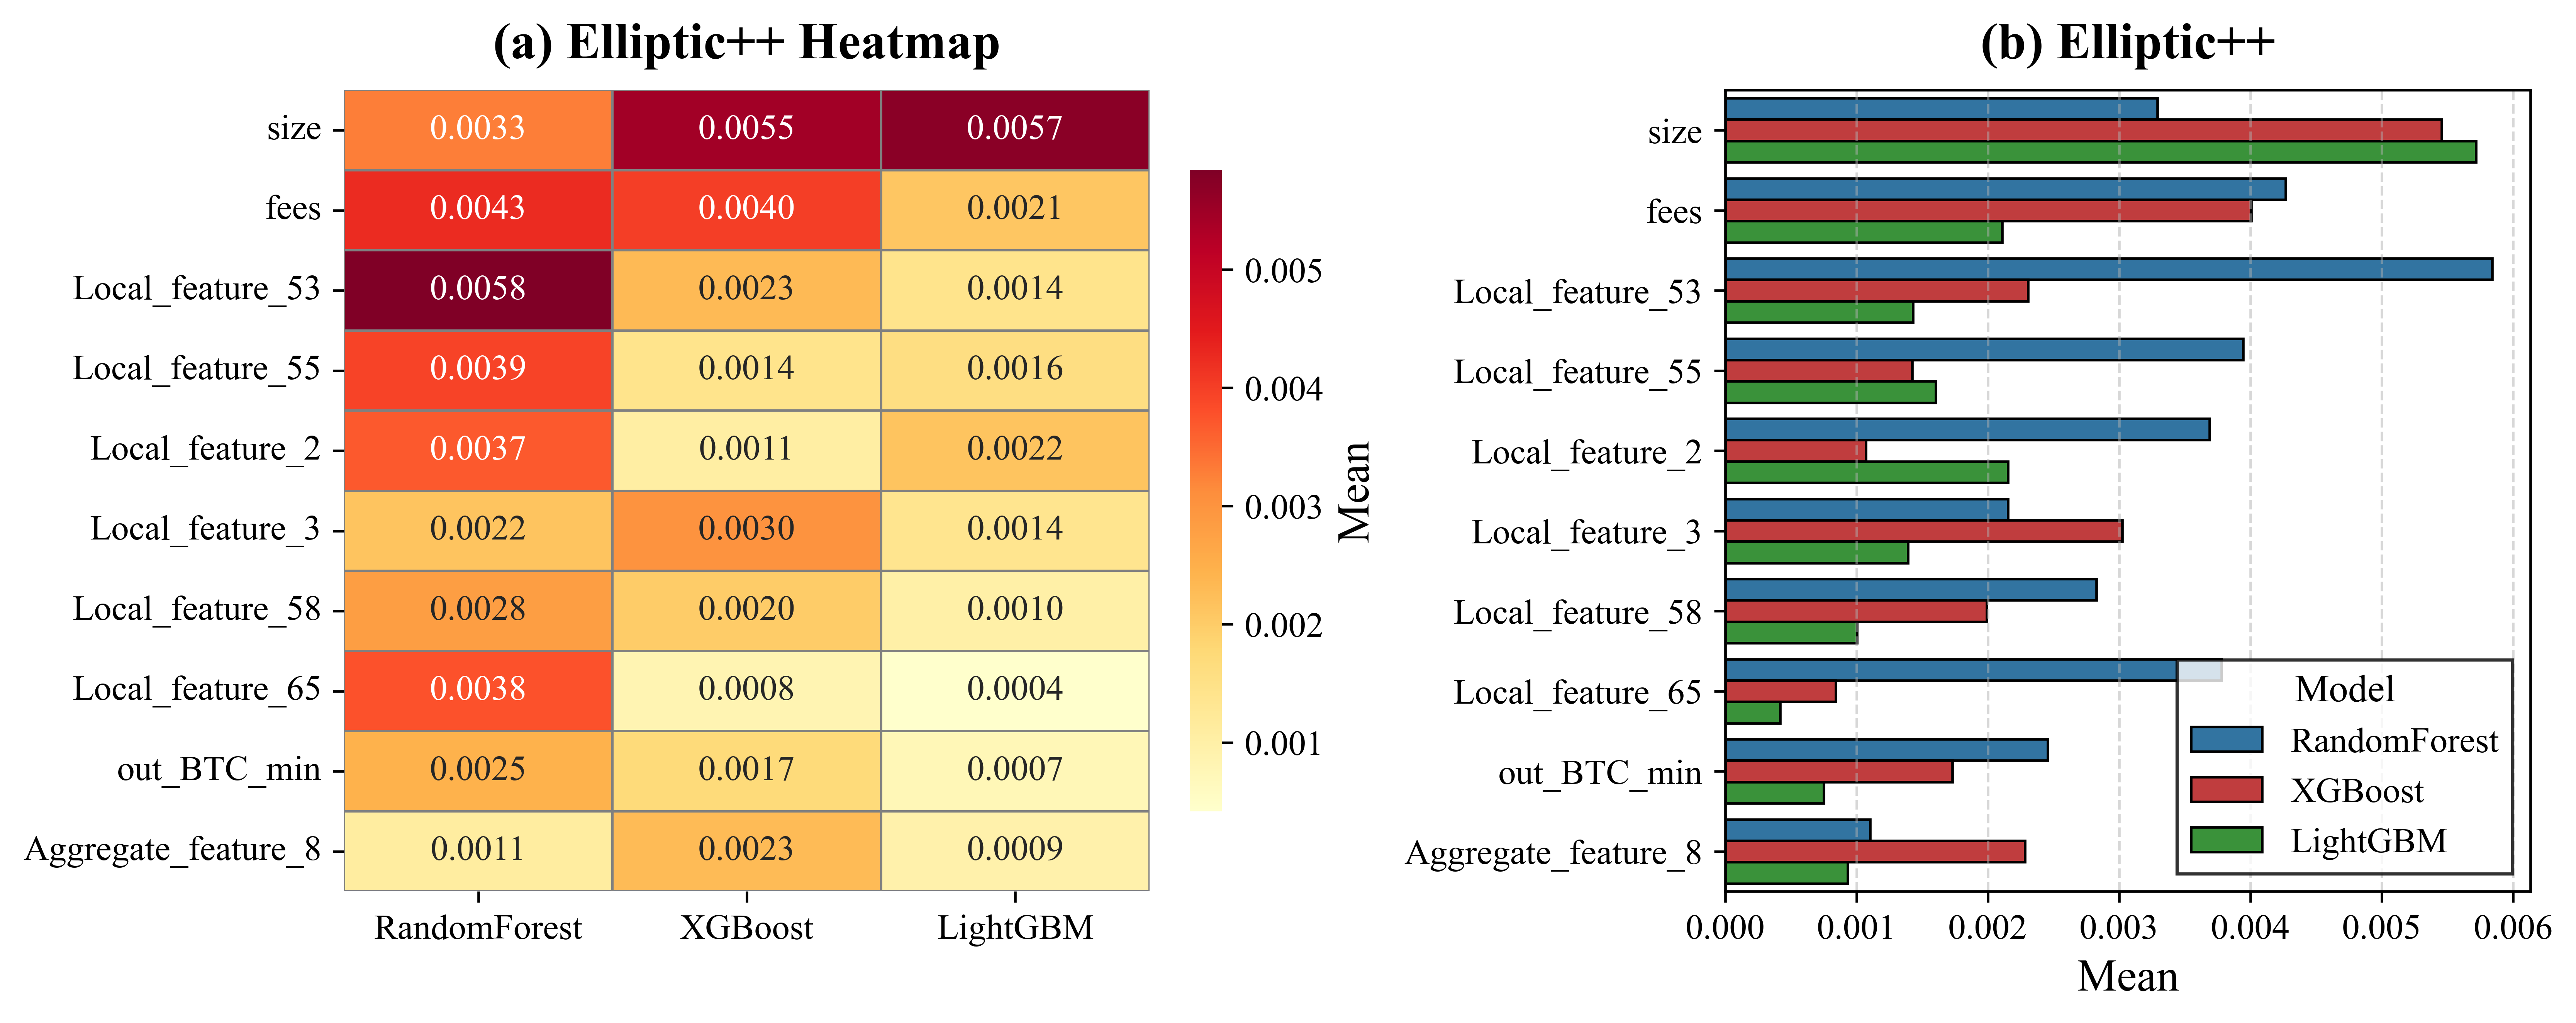

In [ ]:
# # =========================================
# # 10. SHAP cho Elliptic++ (3 model RF, XGB, LGBM)
# # Vẽ kiểu Springer: (a) Heatmap + (b) Grouped bar
# # =========================================
# try:
#     import shap
#     shap_available = True
# except Exception as e:
#     print("Không thể import SHAP (shap). Hãy cài: pip install shap")
#     print(e)
#     shap_available = False

# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# if shap_available and X_test_scaled.shape[0] > 0:
#     shap.initjs()

#     # -------- 1. STYLE SPRINGER (y như code mẫu) --------
#     plt.rcParams['font.family'] = 'serif'
#     plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
#     plt.rcParams['font.size'] = 12
#     plt.rcParams['axes.labelsize'] = 14
#     plt.rcParams['axes.titlesize'] = 16
#     plt.rcParams['xtick.labelsize'] = 11
#     plt.rcParams['ytick.labelsize'] = 11
#     plt.rcParams['legend.fontsize'] = 11
#     plt.rcParams['figure.titlesize'] = 18

#     # -------- 2. TÍNH SHAP: Mean |SHAP| cho Elliptic++ --------
#     n_background = min(200,X_train_scaled.shape[0])
#     n_explain    = min(200,X_test_scaled.shape[0])

#     X_background = X_train_scaled[:n_background]
#     X_explain    = X_test_scaled[:n_explain]

#     print(f"[Elliptic] Background SHAP size: {X_background.shape}")
#     print(f"[Elliptic] Explain SHAP size   : {X_explain.shape}")

#     models_to_explain = {
#         "RandomForest": best_rf,
#         "XGBoost":      best_xgb,
#         "LightGBM":     best_lgbm,
#     }

#     mean_abs_dict = {}   # model_name -> (n_features,)

#     for name, model in models_to_explain.items():
#         print(f"\n================ SHAP cho {name} (Elliptic++) ================")

#         # TreeExplainer, model_output="probability" cho cùng thang
#         explainer = shap.TreeExplainer(
#             model,
#             data=X_background,
#             feature_perturbation="interventional",
#             model_output="probability"
#         )

#         sv = explainer.shap_values(
#             X_explain,
#             check_additivity=False
#         )

#         # ----- Chuẩn hoá về SHAP cho class=1, sv_pos: (n_samples, n_features) -----
#         if isinstance(sv, list):
#             if hasattr(model, "classes_"):
#                 cls_idx = int(np.where(model.classes_ == 1)[0][0])
#             else:
#                 cls_idx = 1
#             sv_pos = np.array(sv[cls_idx])

#         elif isinstance(sv, np.ndarray) and sv.ndim == 3:
#             if hasattr(model, "classes_"):
#                 cls_idx = int(np.where(model.classes_ == 1)[0][0])
#             else:
#                 cls_idx = sv.shape[2] - 1
#             sv_pos = np.array(sv[:, :, cls_idx])

#         else:
#             sv_pos = np.array(sv)

#         assert sv_pos.ndim == 2, f"sv_pos không phải 2D cho model {name} (shape={sv_pos.shape})"
#         print("  sv_pos.shape =", sv_pos.shape, "| ndim =", sv_pos.ndim)

#         # Mean absolute SHAP value cho mỗi feature
#         mean_abs = np.mean(np.abs(sv_pos), axis=0)   # shape = (n_features,)
#         mean_abs_dict[name] = mean_abs

#     # -------- 3. TẠO BẢNG MEAN |SHAP| (giống "Importance" code mẫu) --------
#     df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)

#     # chọn top_n feature theo trung bình across models
#     top_n = 10 if len(feature_cols) >= 10 else len(feature_cols)
#     df_mean['avg'] = df_mean.mean(axis=1)
#     df_mean = df_mean.sort_values('avg', ascending=False)
#     df_top = df_mean.head(top_n).drop(columns='avg')   # (top_n x 3)

#     # -------- 4. VẼ (a) Heatmap + (b) Grouped bar – SPRINGER --------
#     plt.close('all')
#     fig, axes = plt.subplots(
#         1, 2,
#         figsize=(11, 4.3),   # 1 dòng trong layout (11, 13) của code mẫu
#         dpi=600,
#         constrained_layout=True
#     )
#     ax0, ax1 = axes

#     # ---------- (a) Heatmap: KHÔNG CHUẨN HOÁ, dùng Mean |SHAP| gốc ----------
#     sns.heatmap(
#         df_top,
#         annot=True,
#         fmt=".4f",                 # SHAP thật thường nhỏ, 4 số lẻ
#         cmap="YlOrRd",
#         linewidths=0.5,
#         linecolor='gray',
#         cbar_kws={"label": "Mean", "shrink": 0.8},
#         ax=ax0,
#         annot_kws={"size": 11}
#     )

#     ax0.set_title("(a) Elliptic++ Heatmap", pad=10, fontweight='bold')
#     ax0.set_xlabel("")
#     ax0.set_ylabel("")
#     ax0.set_yticklabels(df_top.index, rotation=0)
#     ax0.set_xticklabels(df_top.columns, rotation=0)

#     # ---------- (b) Grouped bar: giống plot_grouped_bar code mẫu ----------
#     df_long = (
#         df_top
#         .reset_index()
#         .melt(id_vars="index", var_name="Model", value_name="Importance")
#         .rename(columns={"index": "Feature"})
#     )

#     feature_order = df_top.index.tolist()

#     sns.barplot(
#         data=df_long,
#         x="Importance",
#         y="Feature",
#         hue="Model",
#         order=feature_order,
#         palette=["#1f77b4", "#d62728", "#2ca02c"],  # giống code mẫu
#         ax=ax1,
#         edgecolor='black',
#         linewidth=0.8
#     )

#     ax1.set_title("(b) Elliptic++", pad=10, fontweight='bold')
#     ax1.set_xlabel("Mean")
#     ax1.set_ylabel("")
#     ax1.grid(axis="x", linestyle='--', alpha=0.5)

#     ax1.legend(
#         title="Model",
#         frameon=True,
#         fancybox=False,
#         edgecolor='black'
#     )

#     plt.show()

#     # (tuỳ chọn) nếu vẫn muốn giải thích local cho 1 node bằng XGBoost thì có thể thêm block riêng ở dưới,
#     # tương tự như bạn làm cho Ethereum/BLTE.
# else:
#     print("Bỏ qua SHAP Elliptic++ vì không sẵn sàng hoặc không có mẫu test.")


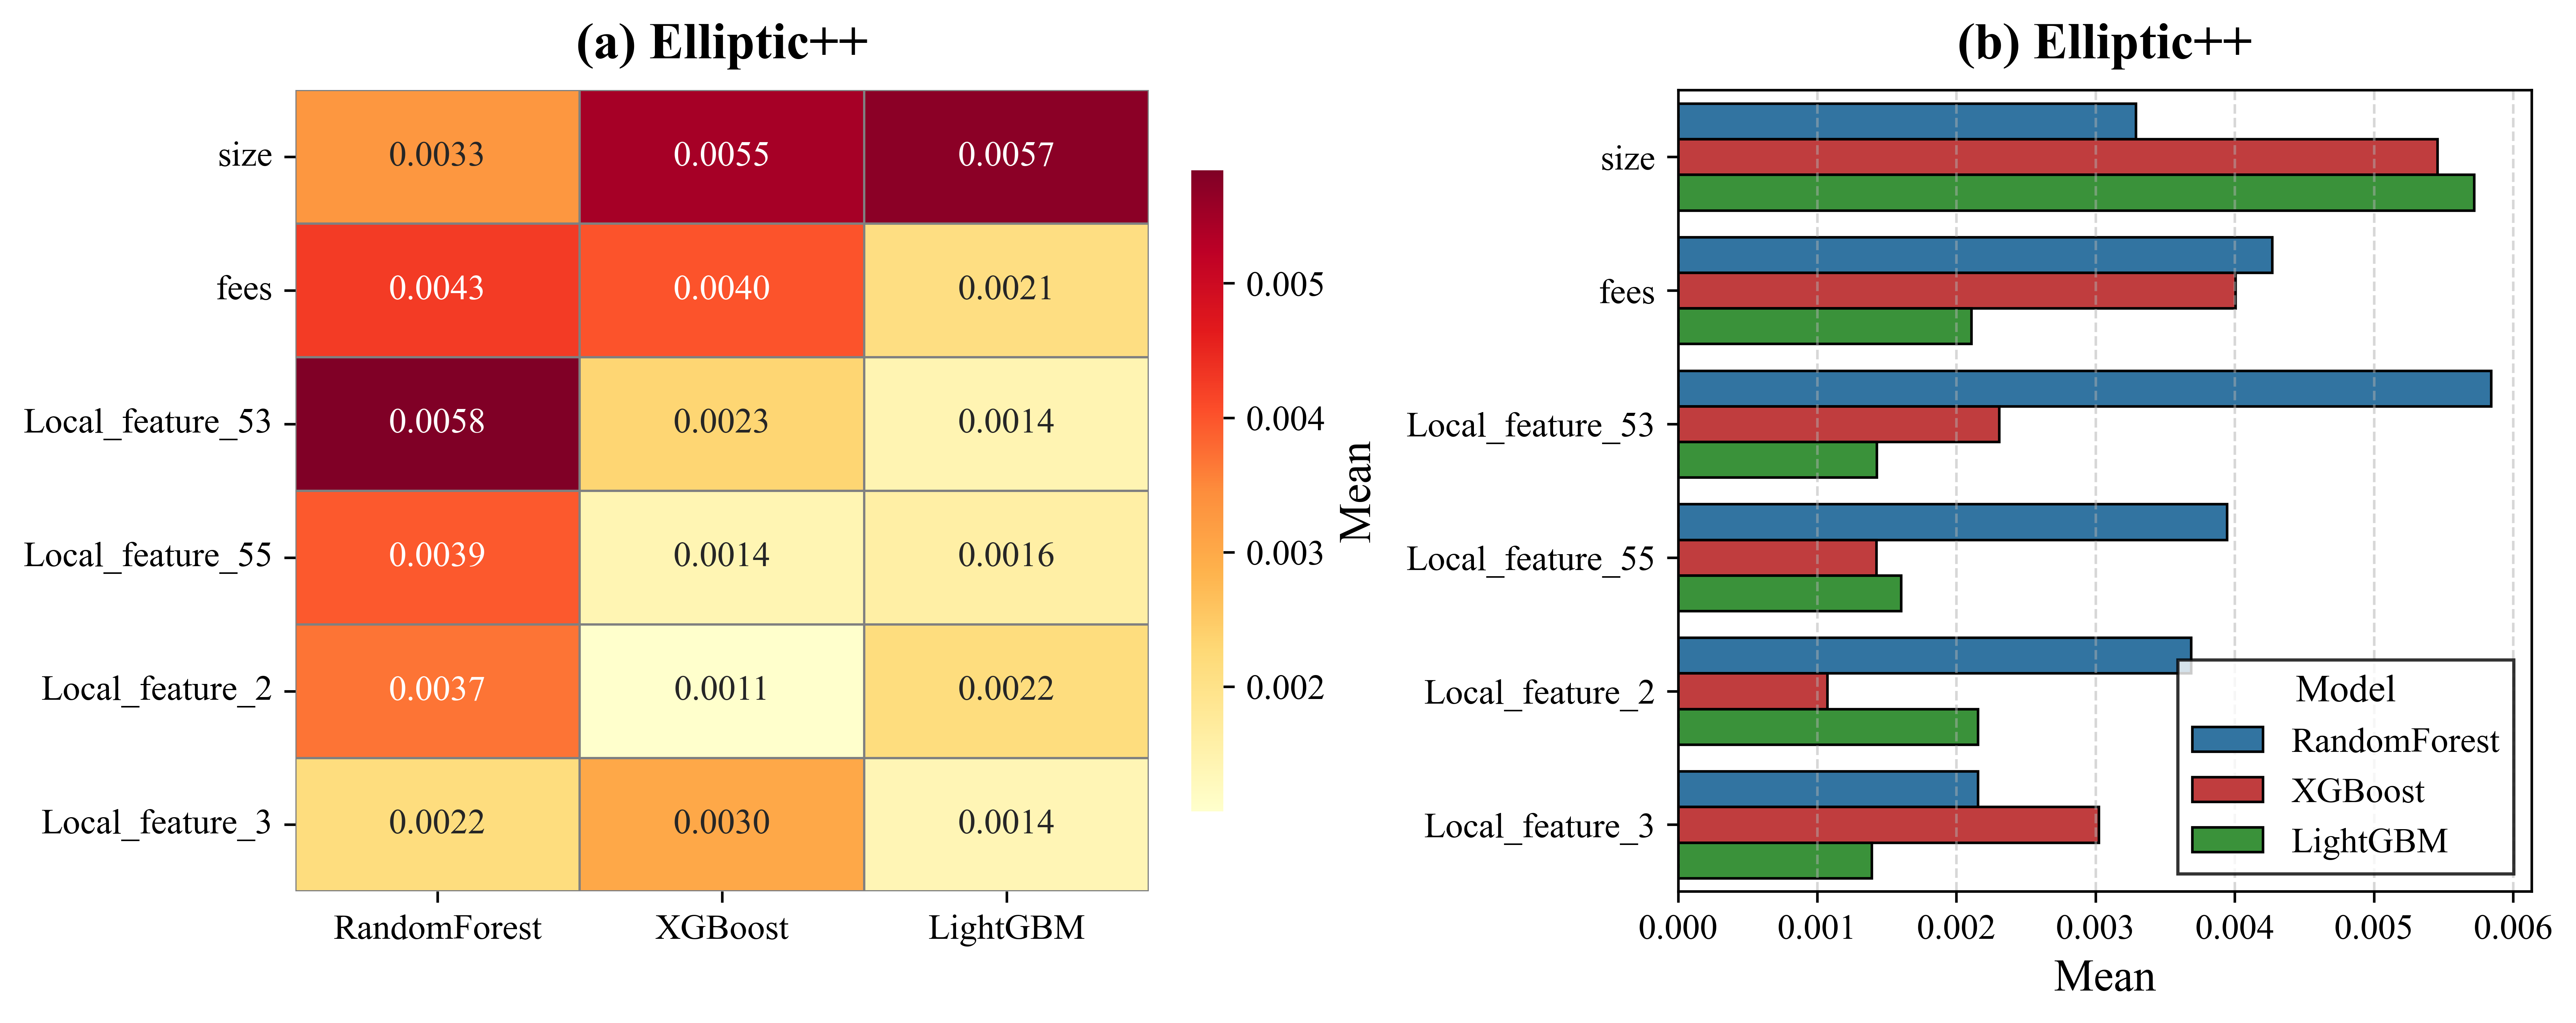

In [ ]:
    # # -------- 3. TẠO BẢNG MEAN |SHAP| (giống "Importance" code mẫu) --------
    # df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)

    # # chọn top_n feature theo trung bình across models
    # top_n = 6 if len(feature_cols) >= 10 else len(feature_cols)
    # df_mean['avg'] = df_mean.mean(axis=1)
    # df_mean = df_mean.sort_values('avg', ascending=False)
    # df_top = df_mean.head(top_n).drop(columns='avg')   # (top_n x 3)

    # # -------- 4. VẼ (a) Heatmap + (b) Grouped bar – SPRINGER --------
    # plt.close('all')
    # fig, axes = plt.subplots(
    #     1, 2,
    #     figsize=(11, 4.3),   # 1 dòng trong layout (11, 13) của code mẫu
    #     dpi=600,
    #     constrained_layout=True
    # )
    # ax0, ax1 = axes

    # # ---------- (a) Heatmap: KHÔNG CHUẨN HOÁ, dùng Mean |SHAP| gốc ----------
    # sns.heatmap(
    #     df_top,
    #     annot=True,
    #     fmt=".4f",                 # SHAP thật thường nhỏ, 4 số lẻ
    #     cmap="YlOrRd",
    #     linewidths=0.5,
    #     linecolor='gray',
    #     cbar_kws={"label": "Mean", "shrink": 0.8},
    #     ax=ax0,
    #     annot_kws={"size": 11}
    # )

    # ax0.set_title("(a) Elliptic++", pad=10, fontweight='bold')
    # ax0.set_xlabel("")
    # ax0.set_ylabel("")
    # ax0.set_yticklabels(df_top.index, rotation=0)
    # ax0.set_xticklabels(df_top.columns, rotation=0)

    # # ---------- (b) Grouped bar: giống plot_grouped_bar code mẫu ----------
    # df_long = (
    #     df_top
    #     .reset_index()
    #     .melt(id_vars="index", var_name="Model", value_name="Importance")
    #     .rename(columns={"index": "Feature"})
    # )

    # feature_order = df_top.index.tolist()

    # sns.barplot(
    #     data=df_long,
    #     x="Importance",
    #     y="Feature",
    #     hue="Model",
    #     order=feature_order,
    #     palette=["#1f77b4", "#d62728", "#2ca02c"],  # giống code mẫu
    #     ax=ax1,
    #     edgecolor='black',
    #     linewidth=0.8
    # )

    # ax1.set_title("(b) Elliptic++", pad=10, fontweight='bold')
    # ax1.set_xlabel("Mean")
    # ax1.set_ylabel("")
    # ax1.grid(axis="x", linestyle='--', alpha=0.5)

    # ax1.legend(
    #     title="Model",
    #     frameon=True,
    #     fancybox=False,
    #     edgecolor='black'
    # )

    # fig.savefig("eliptic.png", dpi=600, bbox_inches="tight")

    # # (tuỳ chọn) nếu vẫn muốn giải thích local cho 1 node bằng XGBoost thì có thể thêm block riêng ở dưới,
    # # tương tự như bạn làm cho Ethereum/BLTE.


In [ ]:
# from pathlib import Path
# import pandas as pd
# from sklearn.metrics import f1_score

# rows = []

# # ===== 3 base models =====
# base_models = {"RF": best_rf, "XGB": best_xgb, "LGBM": best_lgbm}
# for name, model in base_models.items():
#     y_pred = model.predict(X_test_scaled)
#     rows.append({
#         "seed": int(RANDOM_STATE),
#         "model": name,
#         "f1_macro": float(f1_score(y_test, y_pred, average="macro"))
#     })

# # ===== 8 ensemble models =====
# if "results_df" in globals():
#     tmp = results_df.copy()
#     tmp["model"] = tmp["ensemble"].astype(str) + "_" + tmp["voting"].astype(str)
#     for _, r in tmp.iterrows():
#         rows.append({
#             "seed": int(RANDOM_STATE),
#             "model": str(r["model"]),
#             "f1_macro": float(r["f1_macro"])
#         })
# else:
#     print("WARNING: results_df chưa tồn tại -> chỉ lưu macro-F1 cho 3 base models.")

# # ===== LƯU CSV (append) =====
# out_csv = Path(r"D:\elliptic\ellipticv2\runs\macro_f1_all_models_by_seed.csv")
# out_csv.parent.mkdir(parents=True, exist_ok=True)

# df_out = pd.DataFrame(rows)

# write_header = (not out_csv.exists()) or out_csv.stat().st_size == 0
# df_out.to_csv(out_csv, mode="a", header=write_header, index=False)

# print("Saved:", out_csv, "| rows:", len(df_out))
